In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *
from sklearn.metrics import accuracy_score

# Load the preprocessed data
train_df = pd.read_csv('../../data/classification/processed/dry_bean/train_scaled.csv')
val_df = pd.read_csv('../../data/classification/processed/dry_bean/val_scaled.csv')
test_df = pd.read_csv('../../data/classification/processed/dry_bean/test_scaled.csv')

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values
X_val = val_df.iloc[:, :-1].values
y_val = val_df.iloc[:, -1].values
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (9480, 16), Test size: (2032, 16)


# I. Logistic Regression (nhị phân và đa lớp)

## 1. Biểu thức toán học Logistic Regression
### Gradient và Hessian:
- Gradient của Softmax (cross-entropy direct multinomial): $\nabla E = \frac{1}{N} \sum_{n=1}^N (\mathbf{y}_n - \mathbf{t}_n)\mathbf{x}_n^T$ 
- Hessian cho Binary LR (để tính Newton-Raphson): $H = \Phi^T R \Phi$ nơi $R = diag(y_n(1 - y_n))$.
Việc sử dụng phương pháp **Newton-Raphson (IRLS)** tốn nhiều chi phí vì thao tác nghịch đảo ma trận $H$ kích thước $(D+1, D+1)$, dẫn đến giới hạn của việc huấn luyện trên tập Features siêu đa chiều.

## 2. Thí nghiệm Binary: Gradient Descent vs Newton-Raphson
Gián lược bài toán K=7 thành Binary thông qua việc lọc 2 loại đậu phổ biến nhất là DERMASON (5) và SIRA (6) để quan sát hội tụ Hessian và Gradient.

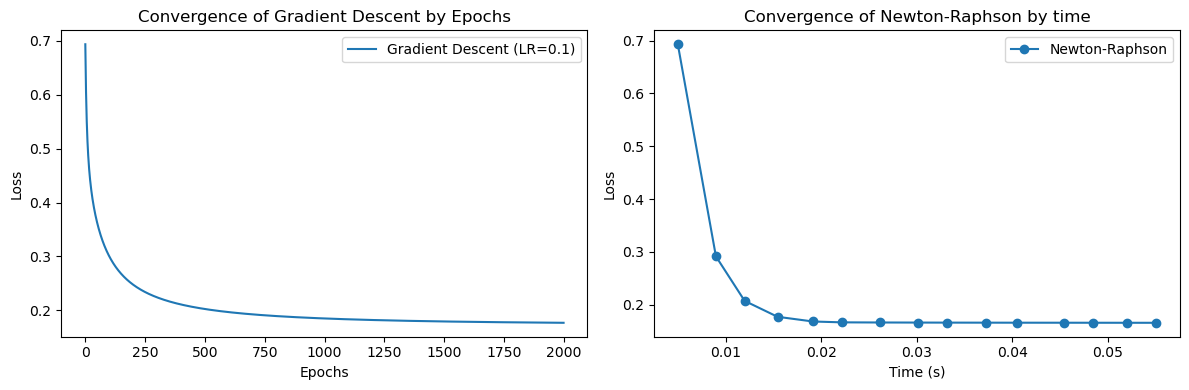

Accuracy Gradient Descent: 0.9266
Accuracy Newton-Raphson: 0.9310


In [2]:
# Get 2 class names for binary classification
mask_train = (y_train == 'DERMASON') | (y_train == 'SIRA')
mask_val = (y_val == 'DERMASON') | (y_val == 'SIRA')

X_bin_train, y_bin_train = X_train[mask_train], y_train[mask_train]
X_bin_val, y_bin_val = X_val[mask_val], y_val[mask_val]

# Encode labels: SIRA=0, DERMASON=1
y_bin_train = (y_bin_train == 'SIRA').astype(int)
y_bin_val = (y_bin_val == 'SIRA').astype(int)

# Model 1: Gradient Descent
model_gd = LogisticRegressionGD(learning_rate=0.1, max_epochs=2000)
model_gd.fit(X_bin_train, y_bin_train)

# Model 2: Newton-Raphson
model_nt = LogisticRegressionNewton(max_epochs=15, tol=1e-5)
model_nt.fit(X_bin_train, y_bin_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Loss vs Epoch for GD
ax1.plot(model_gd.loss_history, label='Gradient Descent (LR=0.1)')
ax1.set_title("Convergence of Gradient Descent by Epochs")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss")
ax1.legend()

# Loss vs Time for Newton-Raphson
ax2.plot(model_nt.wall_clock_time, model_nt.loss_history, marker='o', label='Newton-Raphson')
ax2.set_title("Convergence of Newton-Raphson by time")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Loss")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Accuracy Gradient Descent: {accuracy_score(y_bin_val, model_gd.predict(X_bin_val)):.4f}")
print(f"Accuracy Newton-Raphson: {accuracy_score(y_bin_val, model_nt.predict(X_bin_val)):.4f}")

## 3. Thí nghiệm Multi-class (7 Classes): OVR, OVO, Softmax
Thực chiến lại độ hiệu quả thuật toán trực tiếp trên toàn bộ dữ liệu 7 lớp gốc kết hợp với base module (Binary Gradient Descent).
`OneVsOne` (OVO) sẽ tiêu tốn thời gian hơn đáng kể vì đòi hỏi phải training tới $\frac{7 \times 6}{2} = 21$ networks độc lập.

In [3]:
import time

base_lr = LogisticRegressionGD(learning_rate=0.1, max_epochs=500)

print("Training One-Vs-Rest...")
ovr_model = OneVsRestClassifier(estimator=base_lr)
t_start = time.time(); ovr_model.fit(X_train, y_train); t_ovr = time.time() - t_start

print("Training One-Vs-One...")
ovo_model = OneVsOneClassifier(estimator=base_lr)
t_start = time.time(); ovo_model.fit(X_train, y_train); t_ovo = time.time() - t_start

print("Training Softmax (Multinomial direct)...")
softmax_model = LogisticRegressionGD(learning_rate=0.1, max_epochs=500, multi_class='multinomial')
t_start = time.time(); softmax_model.fit(X_train, y_train); t_soft = time.time() - t_start

acc_ovr = accuracy_score(y_val, ovr_model.predict(X_val))
acc_ovo = accuracy_score(y_val, ovo_model.predict(X_val))
acc_soft = accuracy_score(y_val, softmax_model.predict(X_val))

results = pd.DataFrame({
    'Strategy': ['OVR', 'OVO', 'Softmax'],
    'Accuracy': [acc_ovr, acc_ovo, acc_soft],
    'Time (s)': [t_ovr, t_ovo, t_soft]
})
results

Training One-Vs-Rest...
Training One-Vs-One...
Training Softmax (Multinomial direct)...


,Strategy,Accuracy,Time (s)
0,OVR,0.848351,2.833179
1,OVO,0.908912,6.042669
2,Softmax,0.887740,1.931451


# II. Linear Discriminant Analysis – LDA và QDA

## 1. LDA và QDA

In [4]:
# Encode labels for LDA/QDA

y_train_raw = y_train

# Get unique class names and create mappings
class_names = np.sort(np.unique(y_train_raw))
label_to_int = {label: idx for idx, label in enumerate(class_names)}
int_to_label = {idx: label for label, idx in label_to_int.items()}

y_train_t = np.array([label_to_int[label] for label in y_train_raw], dtype=int)
if y_test is not None:
    y_test = np.array([label_to_int.get(label, -1) for label in y_test], dtype=int)
    if np.any(y_test == -1):
        unknown = np.unique(y_test[y_test == -1])
        raise ValueError(f"Test set labels not in train train: {unknown}")
else:
    y_test = None
    
# ---- LDA ----
lda = LDA_Scratch()
lda.fit(X_train, y_train_t)
y_pred_lda = lda.predict(X_test)
if y_test is not None:
    print('LDA test accuracy:', accuracy(y_test, y_pred_lda))
    display(confusion_matrix_df(y_test, y_pred_lda, class_names))
else:
    print('Finished training LDA. Test set has no labels, showing prediction distribution:')
    values, counts = np.unique(y_pred_lda, return_counts=True)
    display(pd.DataFrame({'Class': class_names[values], 'Count': counts}).sort_values('Count', ascending=False))

# ---- QDA ----
qda = QDA_Scratch()
qda.fit(X_train, y_train_t)
y_pred_qda = qda.predict(X_test)
if y_test is not None:
    print('QDA test accuracy:', accuracy(y_test, y_pred_qda))
    display(confusion_matrix_df(y_test, y_pred_qda, class_names))
else:
    print('Finished training QDA. Test set has no labels, showing prediction distribution:')
    values, counts = np.unique(y_pred_qda, return_counts=True)
    display(pd.DataFrame({'Class': class_names[values], 'Count': counts}).sort_values('Count', ascending=False))

LDA test accuracy: 0.8976377952755905


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
BARBUNYA,169,0,17,0,0,3,9
BOMBAY,0,78,0,0,0,0,0
CALI,8,0,228,0,5,0,4
DERMASON,0,0,0,437,0,12,83
HOROZ,0,0,16,2,254,0,7
SEKER,1,0,0,2,0,286,15
SIRA,0,0,0,18,5,1,372


QDA test accuracy: 0.8976377952755905


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
BARBUNYA,176,0,11,0,1,5,5
BOMBAY,0,78,0,0,0,0,0
CALI,6,0,232,0,4,0,3
DERMASON,0,0,0,416,2,2,112
HOROZ,0,0,11,2,264,0,2
SEKER,1,0,1,5,0,280,17
SIRA,0,0,1,10,7,0,378


## 2. Tính Fisher ratio J(w) cho từng đặc trưng, xếp hạng độ phân biệt lớp.

In [5]:
feature_names = train_df.drop(columns=['Class']).columns.to_list()

ranked_indices, fisher_scores = rank_features_fisher(X_train, y_train, feature_names)

fisher_df = pd.DataFrame({
    'feature': feature_names,
    'fisher_J': fisher_scores,
}).sort_values('fisher_J', ascending=False).reset_index(drop=True)

display(fisher_df)

Ranking features by Fisher Ratio J(w):
1. Perimeter (J = 6.6412)
2. MajorAxisLength (J = 6.6321)
3. ShapeFactor2 (J = 6.2617)
4. ConvexArea (J = 5.8794)
5. EquivDiameter (J = 5.8157)
6. Area (J = 5.8047)
7. ShapeFactor3 (J = 4.5162)
8. Compactness (J = 4.5089)
9. AspectRation (J = 4.4146)
10. MinorAxisLength (J = 4.3640)
11. Eccentricity (J = 4.2958)
12. ShapeFactor1 (J = 4.2629)
13. roundness (J = 3.3640)
14. ShapeFactor4 (J = 1.0717)
15. Solidity (J = 0.4636)
16. Extent (J = 0.1081)


,feature,fisher_J
0,Perimeter,6.641180
1,MajorAxisLength,6.632082
2,ShapeFactor2,6.261740
3,ConvexArea,5.879395
4,EquivDiameter,5.815695
5,Area,5.804702
6,ShapeFactor3,4.516158
7,Compactness,4.508938
8,AspectRation,4.414576
9,MinorAxisLength,4.364026


## 3. Vẽ quy chiếu LDA xuống 2D và biểu diễn đường biên quyết định (decision boundary).

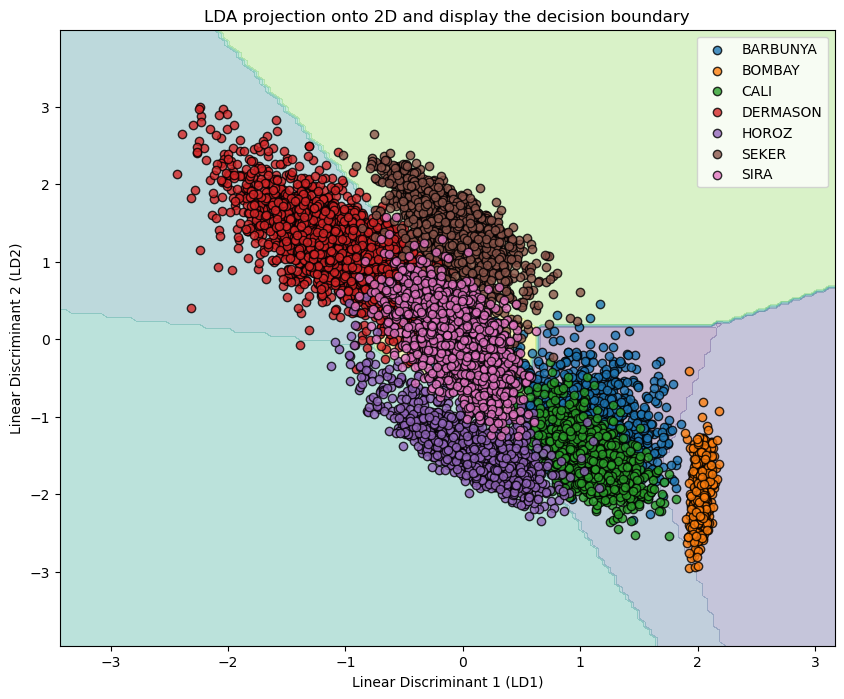

In [6]:
# Draw the LDA projection onto 2D and display the decision boundary.
project_lda_2d_and_plot(X_train, y_train_t, class_names)

## 4. Phân tích khi nào LDA tốt hơn QDA và ngược lại (liên hệ với số mẫu và số chiều).

### Giả định mô hình
- **LDA**: mỗi lớp có phân phối Gaussian với **cùng** ma trận hiệp phương sai $\Sigma$ (chung), khác mean $\mu_k$. Biên quyết định **tuyến tính**.
- **QDA**: mỗi lớp có Gaussian với **ma trận hiệp phương sai riêng** $\Sigma_k$. Biên quyết định **bậc hai** (conic).

### Liên hệ số mẫu $n$, số chiều $d$, số lớp $K$
- Ước lượng hiệp phương sai có số tham số khoảng $\frac{d(d+1)}{2}$.
- **LDA** cần 1 ma trận $\Sigma$ chung $\Rightarrow$ khoảng $\frac{d(d+1)}{2}$ tham số cho covariance.
- **QDA** cần $K$ ma trận $\Sigma_k$ riêng $\Rightarrow$ khoảng $K\cdot\frac{d(d+1)}{2}$ tham số cho covariance.

### Khi nào LDA thường tốt hơn QDA?
- **Ít mẫu / nhiều chiều**: $n$ không đủ lớn so với $d$ (đặc biệt là mỗi lớp $n_k$ nhỏ). QDA phải ước lượng quá nhiều tham số nên dễ **overfit**.
- Khi dữ liệu **gần đúng** thỏa giả định “các lớp có covariance tương tự nhau”. LDA ít tham số nên tổng quát hóa tốt hơn.
- Khi $d$ tăng, việc ước lượng và nghịch đảo $\Sigma_k$ trong QDA có thể **kém ổn định** (dễ gần suy biến) nếu $n_k$ không đủ lớn.

### Khi nào QDA thường tốt hơn LDA?
- **Nhiều mẫu** (đặc biệt là **mỗi lớp** đều có $n_k$ đủ lớn) để ước lượng $\Sigma_k$ ổn định.
- Khi các lớp thực sự có **covariance khác nhau rõ rệt** (hình dạng/độ trải theo các trục khác nhau), biên bậc hai của QDA mô hình hóa tốt hơn.
- Khi ranh giới phân lớp trong không gian đặc trưng là **phi tuyến** theo dạng “đường cong bậc hai” và dữ liệu đủ để học được dạng này.

### Quy tắc kinh nghiệm (heuristic)
- Nếu $n_k$ không “lớn hơn đáng kể” so với $d$ (ví dụ $n_k$ chỉ cỡ vài lần $d$), QDA thường rủi ro hơn LDA.
- Nếu $n$ rất lớn và bạn nghi ngờ covariance khác nhau theo lớp, QDA có cơ hội vượt LDA.

Trong bài này, dữ liệu có $d=16$ và số lớp $K=7$. Bạn có thể so sánh accuracy LDA/QDA trên tập test như ở phần huấn luyện; nếu hai mô hình gần như nhau, đó là dấu hiệu LDA đã đủ tốt hoặc dữ liệu không cần biên bậc hai phức tạp.

# III. Perceptron và Logistic Regression có Regularization

## 1. Thuật toán Perceptron


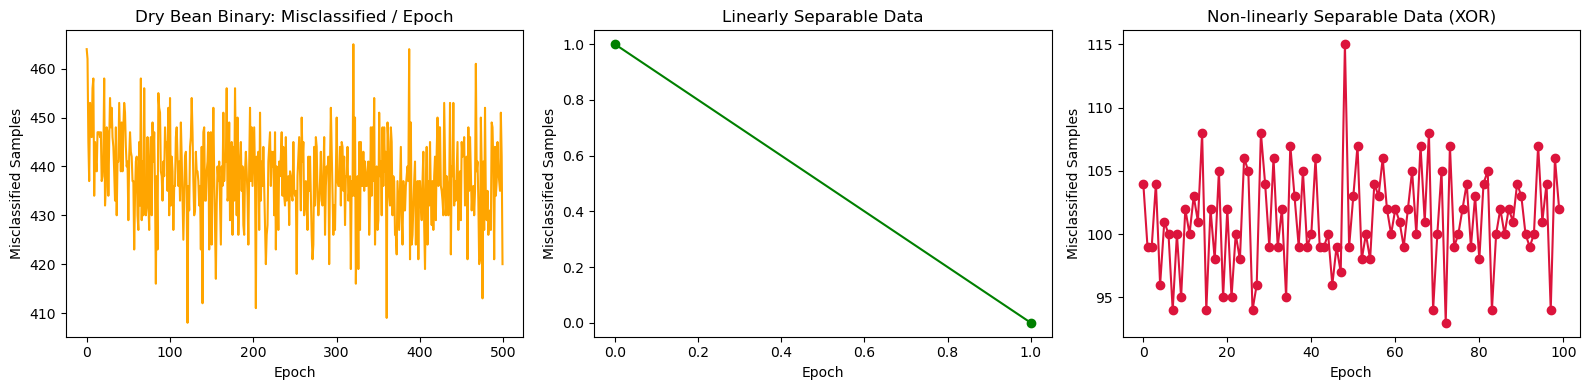

Perceptron Validation Accuracy (Dry Bean): 0.8652
Separable demo converged        : True
Separable demo final mistakes   : 0
Non-separable demo converged    : False
Non-separable demo final mistakes: 102


In [7]:
perceptron = Perceptron(learning_rate=0.01, max_epochs=500)
perceptron.fit(X_bin_train, y_bin_train)
real_val_acc = accuracy_score(y_bin_val, perceptron.predict(X_bin_val))

# 2 dataset separable and non-separable 
X_sep, y_sep = make_perceptron_demo_data(n_samples=200, kind='separable', random_state=42)
X_nonsep, y_nonsep = make_perceptron_demo_data(n_samples=200, kind='non_separable', random_state=42)

perceptron_sep = Perceptron(learning_rate=0.1, max_epochs=100)
perceptron_sep.fit(X_sep, y_sep)

perceptron_nonsep = Perceptron(learning_rate=0.1, max_epochs=100)
perceptron_nonsep.fit(X_nonsep, y_nonsep)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(perceptron.errors_history, color='orange')
axes[0].set_title('Dry Bean Binary: Misclassified / Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Misclassified Samples')

axes[1].plot(perceptron_sep.errors_history, marker='o', color='green')
axes[1].set_title('Linearly Separable Data')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Misclassified Samples')

axes[2].plot(perceptron_nonsep.errors_history, marker='o', color='crimson')
axes[2].set_title('Non-linearly Separable Data (XOR)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Misclassified Samples')

plt.tight_layout()
plt.show()

print(f"Perceptron Validation Accuracy (Dry Bean): {real_val_acc:.4f}")
print(f"Separable demo converged        : {perceptron_sep.errors_history[-1] == 0}")
print(f"Separable demo final mistakes   : {perceptron_sep.errors_history[-1]}")
print(f"Non-separable demo converged    : {perceptron_nonsep.errors_history[-1] == 0}")
print(f"Non-separable demo final mistakes: {perceptron_nonsep.errors_history[-1]}")


## 2. Tinh chỉnh mô hình (Model Tuning) và Tối ưu hóa (Optimization) cho Logistic Regression (LR).

### 2.1 Áp dụng L1 và L2 regularization cho Logistic Regression, so sánh sparsity và hiệu năng.
### 2.2 Chọn $\lambda$ bằng stratified k-fold CV (k = 5) để giữ tỷ lệ lớp trong mỗi fold.
### 2.3 Cài đặt class-weighted loss để xử lý mất cân bằng: $E = \sum_{n,k} c_{k} t_{nk} \ln{y_{nk}}$ với $c_{k} \propto N / N_{k}$


,penalty,C,lambda,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
0,l2,0.10,10.00,0.919807,0.009400,0.923788,0.912240,0.932948,0.906358,0.923699
1,l2,1.00,1.00,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
2,l2,5.00,0.20,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
3,l2,10.00,0.10,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
4,l2,20.00,0.05,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
5,l2,50.00,0.02,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
6,l2,0.01,100.00,0.914261,0.010311,0.915704,0.906467,0.928324,0.899422,0.921387


,penalty,C,lambda,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
0,l1,0.10,10.00,0.920500,0.009023,0.922633,0.916859,0.934104,0.906358,0.922543
1,l1,1.00,1.00,0.919806,0.009178,0.923788,0.915704,0.932948,0.905202,0.921387
2,l1,5.00,0.20,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
3,l1,10.00,0.10,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
4,l1,20.00,0.05,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
5,l1,50.00,0.02,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
6,l1,0.01,100.00,0.899005,0.006659,0.905312,0.897229,0.906358,0.887861,0.898266


Best L2 C from stratified 5-fold CV: 0.1 (lambda=10.0000)
Best L1 C from stratified 5-fold CV: 0.1 (lambda=10.0000)
Accuracy No Penalty        : 0.9202
Accuracy L2 (class_weighted) : 0.9191
Accuracy L1 (class_weighted) : 0.9180


,Model,threshold,near_zero_count,total_count,near_zero_ratio
0,No Penalty,0.001,0,16,0.0
1,"L2 (C=0.1, lambda=10.0000)",0.001,0,16,0.0
2,"L1 (C=0.1, lambda=10.0000)",0.001,0,16,0.0


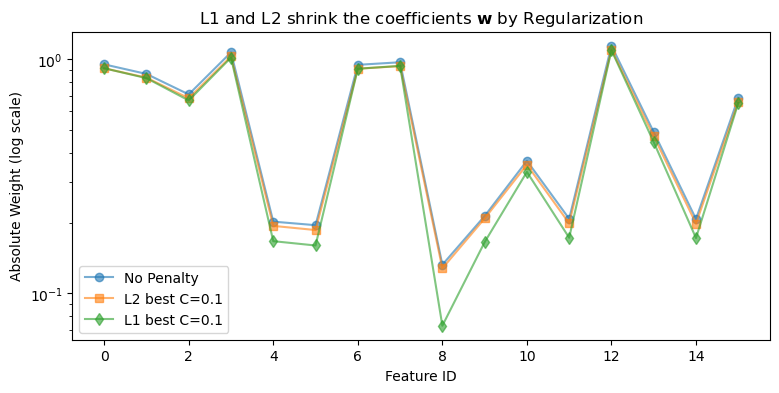

In [8]:
# Grid C, lambda = 1 / C
C_grid = [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0]

# Stratified 5-fold CV
cv_l2 = tune_logistic_reg_stratified_cv(
    X_bin_train, y_bin_train,
    C_values=C_grid,
    penalty='l2',
    learning_rate=0.1,
    max_epochs=500,
    class_weight='balanced',
    k=5,
    random_state=42,
)

cv_l1 = tune_logistic_reg_stratified_cv(
    X_bin_train, y_bin_train,
    C_values=C_grid,
    penalty='l1',
    learning_rate=0.1,
    max_epochs=500,
    class_weight='balanced',
    k=5,
    random_state=42,
)

display(cv_l2['results_df'].sort_values('mean_accuracy', ascending=False).reset_index(drop=True))
display(cv_l1['results_df'].sort_values('mean_accuracy', ascending=False).reset_index(drop=True))

# Fit on all train dataset with best from CV
lr_no_pen = LogisticRegressionReg(learning_rate=0.1, penalty='l2', C=0.0, max_epochs=500)
lr_no_pen.fit(X_bin_train, y_bin_train)

lr_l2 = LogisticRegressionReg(
    learning_rate=0.1, penalty='l2', C=cv_l2['best_C'],
    max_epochs=500, class_weight='balanced'
)
lr_l2.fit(X_bin_train, y_bin_train)

lr_l1 = LogisticRegressionReg(
    learning_rate=0.1, penalty='l1', C=cv_l1['best_C'],
    max_epochs=500, class_weight='balanced'
)
lr_l1.fit(X_bin_train, y_bin_train)

acc_no_pen = accuracy_score(y_bin_val, lr_no_pen.predict(X_bin_val))
acc_l2 = accuracy_score(y_bin_val, lr_l2.predict(X_bin_val))
acc_l1 = accuracy_score(y_bin_val, lr_l1.predict(X_bin_val))

sparsity_rows = pd.DataFrame([
    {'Model': 'No Penalty', **compute_weight_sparsity(lr_no_pen.w, threshold=1e-3)},
    {'Model': f'L2 (C={cv_l2["best_C"]}, lambda={cv_l2["best_lambda"]:.4f})', **compute_weight_sparsity(lr_l2.w, threshold=1e-3)},
    {'Model': f'L1 (C={cv_l1["best_C"]}, lambda={cv_l1["best_lambda"]:.4f})', **compute_weight_sparsity(lr_l1.w, threshold=1e-3)},
])

print(f"Best L2 C from stratified 5-fold CV: {cv_l2['best_C']} (lambda={cv_l2['best_lambda']:.4f})")
print(f"Best L1 C from stratified 5-fold CV: {cv_l1['best_C']} (lambda={cv_l1['best_lambda']:.4f})")
print(f"Accuracy No Penalty        : {acc_no_pen:.4f}")
print(f"Accuracy L2 (class_weighted) : {acc_l2:.4f}")
print(f"Accuracy L1 (class_weighted) : {acc_l1:.4f}")
display(sparsity_rows)

# Sparsity
plt.figure(figsize=(9, 4))
plt.plot(np.abs(lr_no_pen.w[1:]), 'o-', label='No Penalty', alpha=0.6)
plt.plot(np.abs(lr_l2.w[1:]), 's-', label=f'L2 best C={cv_l2["best_C"]}', alpha=0.6)
plt.plot(np.abs(lr_l1.w[1:]), 'd-', label=f'L1 best C={cv_l1["best_C"]}', alpha=0.6)
plt.title(r"L1 and L2 shrink the coefficients $\mathbf{w}$ by Regularization")
plt.yscale('log')
plt.ylabel('Absolute Weight (log scale)')
plt.xlabel('Feature ID')
plt.legend()
plt.show()


## 6. [Bonus Nâng Cao]


### 6.1  Mô hình Probit và Xấp xỉ Laplace (Laplace Approximation)
- **Probit Regression**: Sử dụng hàm xác suất tích lũy (CDF Gaussian chuẩn $\Phi(z)$) để thay cho đường cong Sigmoid $\sigma(z)$. Phù hợp xử lý dữ liệu nơi phân chia bị nhiễu.

In [9]:
# Probit Regression
probit = ProbitRegressionGD(learning_rate=0.1, max_epochs=1000)
probit.fit(X_bin_train, y_bin_train)
acc_probit = accuracy_score(y_bin_val, probit.predict(X_bin_val))


print(f"Accuracy Probit Regression  : {acc_probit:.4f}")

Accuracy Probit Regression  : 0.9266


### 6.2 Xấp xỉ Laplace (Laplace Approximation)
- **Xấp xỉ Laplace**: Giải quyết bài toán Maximum A Posteriori (MAP) phân phối Hậu nghiệm cho Logistic Regression, sau đó tính ma trận hiệp phương sai của xác suất Posterior dựa vào nghịch đảo Hessian $H^{-1}$. Xấp xỉ Laplace có lợi thế khi đi kèm tính toán khoảng bất định (Uncertainty Margin). Nó bớt sai dại tự tin cho điểm sample nằm ở vùng quyết định mơ hồ.

Accuracy Laplace Approxi.   : 0.9288


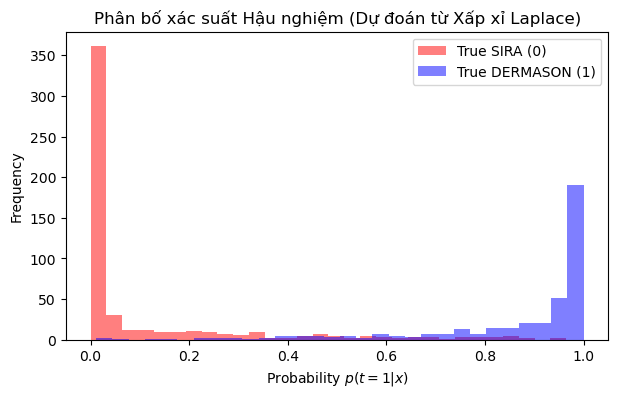

In [10]:
# Laplace Approximation
laplace = LaplaceApproximationLR(lambd=1.0, max_epochs=50)
laplace.fit(X_bin_train, y_bin_train)
acc_laplace = accuracy_score(y_bin_val, laplace.predict(X_bin_val))

prob_pred_laplace = laplace.predict_proba(X_bin_val)[:, 1]

print(f"Accuracy Laplace Approxi.   : {acc_laplace:.4f}")

plt.figure(figsize=(7, 4))
plt.hist(prob_pred_laplace[y_bin_val==0], bins=30, alpha=0.5, label='True SIRA (0)', color='red')
plt.hist(prob_pred_laplace[y_bin_val==1], bins=30, alpha=0.5, label='True DERMASON (1)', color='blue')
plt.title("Phân bố xác suất Hậu nghiệm (Dự đoán từ Xấp xỉ Laplace)")
plt.xlabel("Probability $p(t=1 | x)$")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 6.3 **Kernel Logistic Regression**: cài đặt dual formulation với RBF kernel, so sánh với mô hình tuyến tính trên dữ liệu không phân chia tuyến tính (XOR-like patterns).

Linear Logistic Regression accuracy on XOR-like data : 0.7083
Kernel Logistic Regression (RBF) accuracy            : 1.0000


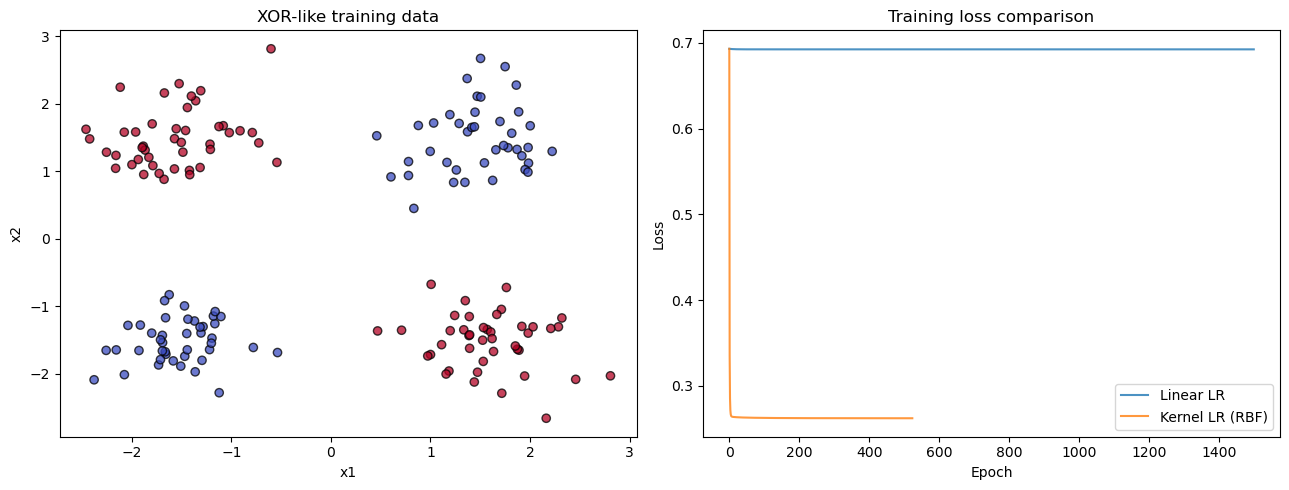

In [11]:
# Kernel Logistic Regression on XOR-like dataset non-separable
X_xor, y_xor = make_kernel_xor_data(n_samples=240, noise=0.45, random_state=42)
X_xor_train, X_xor_test, y_xor_train, y_xor_test = train_test_split_custom(
    X_xor, y_xor, test_size=0.30, random_state=42
)

linear_lr_xor = LogisticRegressionGD(learning_rate=0.1, max_epochs=1500)
linear_lr_xor.fit(X_xor_train, y_xor_train)
acc_linear_xor = accuracy_score(y_xor_test, linear_lr_xor.predict(X_xor_test))

kernel_lr_xor = KernelLogisticRegressionRBF(
    gamma=0.8, lambd=1e-2, learning_rate=0.5, max_epochs=800, tol=1e-7
)
kernel_lr_xor.fit(X_xor_train, y_xor_train)
acc_kernel_xor = accuracy_score(y_xor_test, kernel_lr_xor.predict(X_xor_test))

print(f"Linear Logistic Regression accuracy on XOR-like data : {acc_linear_xor:.4f}")
print(f"Kernel Logistic Regression (RBF) accuracy            : {acc_kernel_xor:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_xor_train[:, 0], X_xor_train[:, 1], c=y_xor_train, cmap='coolwarm', edgecolor='k', alpha=0.75)
axes[0].set_title('XOR-like training data')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

axes[1].plot(linear_lr_xor.loss_history, label='Linear LR', alpha=0.8)
axes[1].plot(kernel_lr_xor.loss_history, label='Kernel LR (RBF)', alpha=0.8)
axes[1].set_title('Training loss comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()


### 6.4 **Gaussian Naive Bayes** vs. **LDA**: so sánh lý thuyết (GNB giả thiết independence, LDA không) và thực nghiệm – khi nào GNB thực tế tốt hơn LDA dù giả thiết kém chặt hơn?

In [12]:
# Gaussian Naive Bayes vs LDA
gnb_lda_rows = []
for case_name, seed in [('correlated_shared_cov', 42), ('independent_small_sample', 7)]:
    n_per_class = 140 if case_name == 'correlated_shared_cov' else 24
    X_case, y_case = make_gnb_lda_demo_data(
        n_samples_per_class=n_per_class,
        case=case_name,
        random_state=seed,
    )
    X_case_train, X_case_test, y_case_train, y_case_test = stratified_train_test_split_custom(
        X_case, y_case, test_size=0.35, random_state=seed
    )

    gnb_case = GaussianNaiveBayesScratch(var_smoothing=1e-9)
    gnb_case.fit(X_case_train, y_case_train)
    lda_case = LDA_Scratch()
    lda_case.fit(X_case_train, y_case_train)

    gnb_acc = accuracy_score(y_case_test, gnb_case.predict(X_case_test))
    lda_acc = accuracy_score(y_case_test, lda_case.predict(X_case_test))
    gnb_lda_rows.append({
        'Scenario': case_name,
        'Train Size': len(y_case_train),
        'Test Size': len(y_case_test),
        'GNB Accuracy': gnb_acc,
        'LDA Accuracy': lda_acc,
        'Better Model': 'GNB' if gnb_acc > lda_acc else 'LDA',
    })

gnb_lda_results = pd.DataFrame(gnb_lda_rows)
display(gnb_lda_results)

bean_classes = np.unique(y_train)
bean_to_int = {cls: idx for idx, cls in enumerate(bean_classes)}
y_train_int = np.array([bean_to_int[v] for v in y_train])
y_val_int = np.array([bean_to_int[v] for v in y_val])

gnb_bean = GaussianNaiveBayesScratch(var_smoothing=1e-9)
gnb_bean.fit(X_train, y_train_int)
lda_bean = LDA_Scratch()
lda_bean.fit(X_train, y_train_int)

print(f"Dry Bean validation accuracy - GNB: {accuracy_score(y_val_int, gnb_bean.predict(X_val)):.4f}")
print(f"Dry Bean validation accuracy - LDA: {accuracy_score(y_val_int, lda_bean.predict(X_val)):.4f}")


,Scenario,Train Size,Test Size,GNB Accuracy,LDA Accuracy,Better Model
0,correlated_shared_cov,273,147,0.884354,0.959184,LDA
1,independent_small_sample,45,27,1.000000,1.000000,LDA


Dry Bean validation accuracy - GNB: 0.8986
Dry Bean validation accuracy - LDA: 0.8941


### 6.5 Phân tích **VC dimension**: tính VC dimension của lớp phân lớp tuyến tính trong $\mathbb{R}^D$ và liên hệ với tổng quát hóa thông qua structural risk minimization.

In [13]:
# VC dimension của lớp phân lớp tuyến tính trong R^D và liên hệ với SRM
feature_slices = [2, 4, X_bin_train.shape[1]]
vc_rows = []
for d in feature_slices:
    model = LogisticRegressionGD(learning_rate=0.1, max_epochs=1500)
    model.fit(X_bin_train[:, :d], y_bin_train)
    train_pred = model.predict(X_bin_train[:, :d])
    val_pred = model.predict(X_bin_val[:, :d])
    train_error = 1.0 - accuracy_score(y_bin_train, train_pred)
    val_accuracy = accuracy_score(y_bin_val, val_pred)
    vc_rows.append({
        'model': f'Linear LR with {d} features',
        'empirical_error': train_error,
        'vc_dim': linear_classifier_vc_dimension(d, include_bias=True),
        'val_accuracy': val_accuracy,
    })

vc_summary = structural_risk_summary(vc_rows, n_samples=len(y_bin_train), delta=0.05)
val_map = {row['model']: row['val_accuracy'] for row in vc_rows}
vc_summary['val_accuracy'] = vc_summary['model'].map(val_map)
display(vc_summary)

full_vc_dim = linear_classifier_vc_dimension(X_bin_train.shape[1], include_bias=True)
print(f"VC dimension of affine linear classifiers in R^{X_bin_train.shape[1]}: {full_vc_dim}")


,model,empirical_error,vc_dim,margin,bound,val_accuracy
0,Linear LR with 2 features,0.086434,3,0.085028,0.171462,0.913700
1,Linear LR with 4 features,0.089438,5,0.103848,0.193286,0.905070
2,Linear LR with 16 features,0.077190,17,0.171546,0.248736,0.926645


VC dimension of affine linear classifiers in R^16: 17
